# 사전 설정

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from scipy import stats
from datetime import datetime

# 경고 무시
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

# === 경고 제어 ===
import warnings
warnings.filterwarnings('ignore')

In [2]:
import platform
# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'
    
# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [3]:
df = pd.read_csv('course_final.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (533993, 31)
Columns: ['course_id', 'userid_DI', 'registered', 'viewed', 'explored', 'certified', 'final_cc_cname_DI', 'LoE_DI', 'YoB', 'gender', 'grade', 'start_time_DI', 'last_event_DI', 'nevents', 'ndays_act', 'nplay_video', 'nchapters', 'nforum_posts', 'viewed_missing_flag', 'duration', 'fast_completion_flag', 'start_year', 'age_raw', 'age_missing_original', 'age_invalid', 'age_cleaned', 'age_final', 'age', 'age_group', 'exam_flag', 'LoE_num']


,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,viewed_missing_flag,duration,fast_completion_flag,start_year,age_raw,age_missing_original,age_invalid,age_cleaned,age_final,age,age_group,exam_flag,LoE_num
0,HarvardX/PH207x/2012_Fall,MHxPC130275857,1,1,1,0,United States,unknown,NaN,unknown,0,2012-09-17,2013-05-23,502.0000,16.0000,50.0000,12.0000,0,0,248,0,2012,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
1,HarvardX/CB22x/2013_Spring,MHxPC130539455,1,1,0,0,France,unknown,NaN,unknown,0,2013-01-01,2013-05-14,42.0000,6.0000,NaN,3.0000,0,0,133,0,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
2,HarvardX/CB22x/2013_Spring,MHxPC130088379,1,1,0,0,United States,unknown,NaN,unknown,0,2013-02-18,2013-03-17,70.0000,3.0000,NaN,3.0000,0,0,27,0,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
3,HarvardX/ER22x/2013_Spring,MHxPC130088379,1,1,0,0,United States,unknown,NaN,unknown,0,2013-02-23,2013-06-14,17.0000,2.0000,NaN,2.0000,0,0,111,0,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
4,HarvardX/ER22x/2013_Spring,MHxPC130198098,1,1,0,0,United States,unknown,NaN,unknown,0,2013-06-17,2013-06-17,32.0000,1.0000,NaN,3.0000,0,0,0,0,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN


- 코스 id 별 카테고리 매핑 추가

# CDA 시작

## 행동 지표와 exp 전환율의 상관행렬
- 각 행동 지표
  - nevents, ndays_act, nchapters, nforum_posts, nplay_video
  - explored에 대한 상관관계를 파악한다

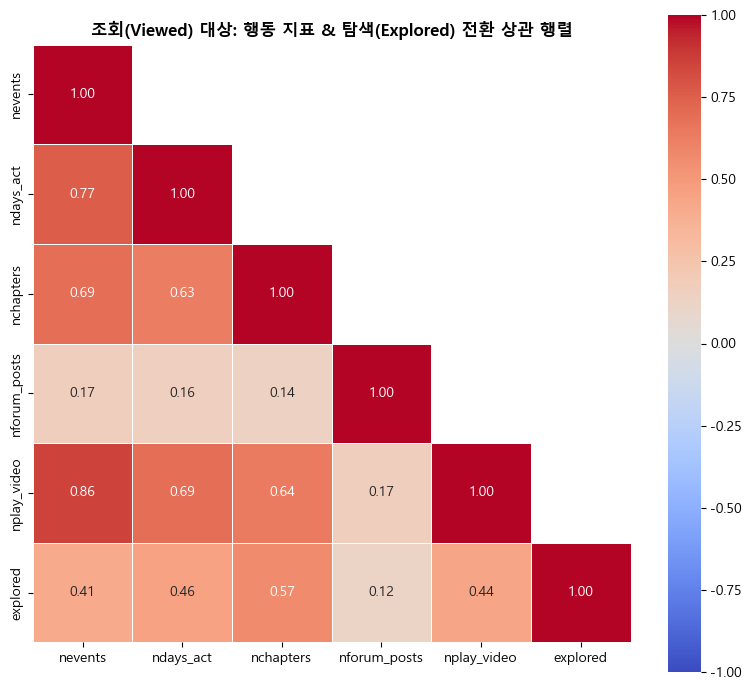

In [4]:
# '조회(View)'를 한 학습자를 기준으로 필터링하여 정확한 상관성을 도출
viewed_df = df[df['viewed'] == 1].copy()

# 'grade' 대신 'explored' 여부 추가 (이진형 데이터 0 or 1 상관계수 도출)
behavior_achievement = ['nevents', 'ndays_act', 'nchapters', 'nforum_posts', 'nplay_video','explored']
corr_matrix = viewed_df[behavior_achievement].corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt='.2f',
    cmap='coolwarm', 
    center=0, 
    ax=ax, 
    vmin=-1, 
    vmax=1,
    square=True, 
    linewidths=0.5
)

# 차트 제목 업데이트
ax.set_title('조회(Viewed) 대상: 행동 지표 & 탐색(Explored) 전환 상관 행렬', fontweight='bold')
plt.tight_layout()
plt.show()


- nchapter가 가장 높긴 하지만, nchapter는 exp 전환의 조건 중 하나로 당연히 상관계수가 높을 수 밖에 없음

## ndays_act & explored 전환율 
- 상관계수(0.46)
- 통계검정 시행

📊 통계 검정 계획: 활동 일수(ndays_act)는 탐색(Explored) 전환에 유의미한 차이를 보일까?     
가설 설정 (Hypothesis)
모수: 코스를 1번이라도 클릭해 본(viewed == 1) 학습자 집단 전체

귀무가설 ($H_0$): 단순 접속자(Explored=0)와 탐색 전환자(Explored=1) 간에 ndays_act(총 활동 일수)의 차이가 없다.     
대립가설 ($H_1$): 탐색 전환자(Explored=1)가 단순 접속자(0)보다 ndays_act가 유의미하게 더 길다. (우측 단측 검정)
- 극심한 왜도로 정규성 불만족 -> 순위 검정 시행
- 맨 휘트니 U 검정 사용

■ 정규성(Normality) 통계 검정 결과 ■
[단순 조회자(0)] p-value: 0.00000e+00 (N=285,970)
[탐색 전환자(1)] p-value: 0.00000e+00 (N=37,584)
* 대용량 데이터 특성상 p-value가 0.05 미만으로 나와 '정규성 기각'이 뜰 확률이 높습니다.
-------------------------------------------------------


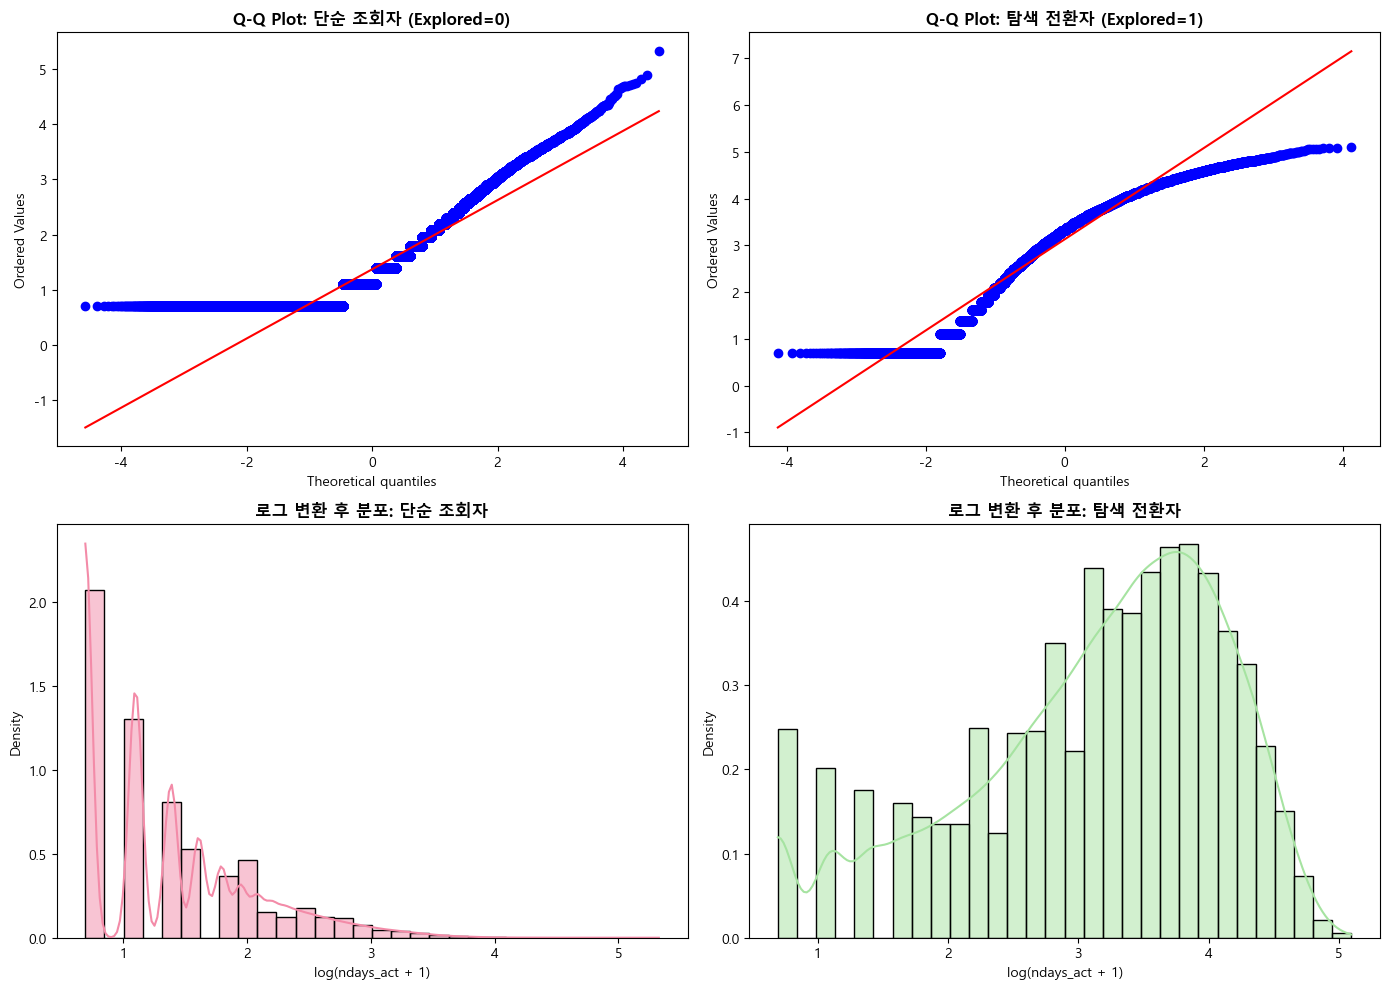

In [7]:
# 1. 데이터 대상 추출 및 로그 변환 (log1p 적용)
# (viewed==1 대상으로 분리)
log_ndays_0 = np.log1p(df[(df['viewed'] == 1) & (df['explored'] == 0)]['ndays_act'].dropna())
log_ndays_1 = np.log1p(df[(df['viewed'] == 1) & (df['explored'] == 1)]['ndays_act'].dropna())

# 2. 정규성 통계 검정 (수만 개 이상의 대용량 데이터에 적합한 D'Agostino's K-squared test)
# H0(귀무가설): 데이터가 정규분포를 따른다.
stat_0, p_0 = stats.normaltest(log_ndays_0)
stat_1, p_1 = stats.normaltest(log_ndays_1)

print("■ 정규성(Normality) 통계 검정 결과 ■")
print(f"[단순 조회자(0)] p-value: {p_0:.5e} (N={len(log_ndays_0):,})")
print(f"[탐색 전환자(1)] p-value: {p_1:.5e} (N={len(log_ndays_1):,})")
print("* 대용량 데이터 특성상 p-value가 0.05 미만으로 나와 '정규성 기각'이 뜰 확률이 높습니다.")
print("-" * 55)

# 3. 데이터 변환 형태 눈으로 확인 (시각화)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 3-1. Q-Q Plot: 파란색 점들이 빨간색 대각선에 일치할수록 완벽한 정규분포를 의미
stats.probplot(log_ndays_0, dist="norm", plot=axes[0, 0])
axes[0, 0].set_title('Q-Q Plot: 단순 조회자 (Explored=0)', fontweight='bold')

stats.probplot(log_ndays_1, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot: 탐색 전환자 (Explored=1)', fontweight='bold')

# 3-2. 히스토그램 + KDE 커널밀도곡선: 실제 종 모양(Bell Curve) 유무 확인
sns.histplot(log_ndays_0, kde=True, bins=30, ax=axes[1, 0], color='#f38ba8', stat='density')
axes[1, 0].set_title('로그 변환 후 분포: 단순 조회자', fontweight='bold')
axes[1, 0].set_xlabel('log(ndays_act + 1)')

sns.histplot(log_ndays_1, kde=True, bins=30, ax=axes[1, 1], color='#a6e3a1', stat='density')
axes[1, 1].set_title('로그 변환 후 분포: 탐색 전환자', fontweight='bold')
axes[1, 1].set_xlabel('log(ndays_act + 1)')

plt.tight_layout()
plt.show()


- log변환해도 정규성 불만족

In [10]:
# 1. 대상 그룹 분리: 조회를 한 번이라도 한 사람(viewed == 1) 중 결측치 제거
group_0 = df[(df['viewed'] == 1) & (df['explored'] == 0)]['ndays_act'].dropna()
group_1 = df[(df['viewed'] == 1) & (df['explored'] == 1)]['ndays_act'].dropna()

# --- 기술 통계 (평균과 중앙값 차이 직관적 확인) ---
print(f"[단순 조회자(0)] 평균: {group_0.mean():.1f}일 | 중앙값: {group_0.median():.0f}일 | 총 {len(group_0):,}명")
print(f"[탐색 전환자(1)] 평균: {group_1.mean():.1f}일 | 중앙값: {group_1.median():.0f}일 | 총 {len(group_1):,}명")

# 2. 비모수 검정: Mann-Whitney U test (탐색집단의 활동일수가 '더 큰가?')
# 💡 여기서 반환되는 stat 변수는 group_1을 기준으로 산출된 U 통계량(U1)입니다.
stat, p_val = stats.mannwhitneyu(group_1, group_0, alternative='greater')

print(f"\n📈 Mann-Whitney U 통계량: {stat}")
print(f"📉 P-value (유의확률): {p_val:.5e}")

if p_val < 0.05:
    print("\n👉 [결론 도출] 통계적으로 유의미합니다! (p < 0.05)")
else:
    print("\n👉 [결론 도출] 통계적으로 유의미한 차이가 없습니다.")


# 3. 비모수 환경에 완벽하게 호환되는 효과 크기: Rank-Biserial Correlation (r_rb) 산출
n1 = len(group_1)
n0 = len(group_0)

# 공식: r_rb = (2 * U1) / (n1 * n0) - 1
# 결과값은 -1 ~ 1 사이로 도출되며, 양수면 group_1(탐색 전환자)의 순위가 더 높음을 의미합니다.
r_rb = (2 * stat) / (n1 * n0) - 1
abs_r = abs(r_rb)

print(f"\n📊 비모수적 효과 크기(Rank-Biserial Correlation): {r_rb:.3f}")

# 효과 크기 가이드라인 (비모수 상관계수 r 기준: 0.1=Small, 0.3=Medium, 0.5=Large)
if abs_r >= 0.5:
    print("   👉 효과 크기가 '매우 큼(Large)' 수준입니다.")
elif abs_r >= 0.3:
    print("   👉 효과 크기가 '중간(Medium)' 수준이며, 탐색 전환율과 꽤 선명한 연관성을 가집니다.")
elif abs_r >= 0.1:
    print("   👉 효과 크기가 '작음(Small)' 수준입니다. 통계적으로는 유의미하나, 다른 요인들도 크게 작용하고 있습니다.")
else:
    print("   👉 효과 크기가 '미미함(Trivial)' 수준입니다. 워낙 사람 수가 많아 p-value가 유의미하게 떴을 뿐입니다.")


[단순 조회자(0)] 평균: 4.2일 | 중앙값: 2일 | 총 285,970명
[탐색 전환자(1)] 평균: 32.7일 | 중앙값: 27일 | 총 37,584명

📈 Mann-Whitney U 통계량: 9742140489.0
📉 P-value (유의확률): 0.00000e+00

👉 [결론 도출] 통계적으로 유의미합니다! (p < 0.05)

📊 비모수적 효과 크기(Rank-Biserial Correlation): 0.813
   👉 효과 크기가 '매우 큼(Large)' 수준입니다.


- ndays_act 단일 컬럼 검정 결과
  - 탐색 집단으로 전환된 사람들의 ndays_act 분포가 유의하게 다름
  - 효과크기도 아주 크다.
  - ndays_act가 높은 집단이 탐색 전환으로 이어지는 경향이 있다.

- 차이 시각화

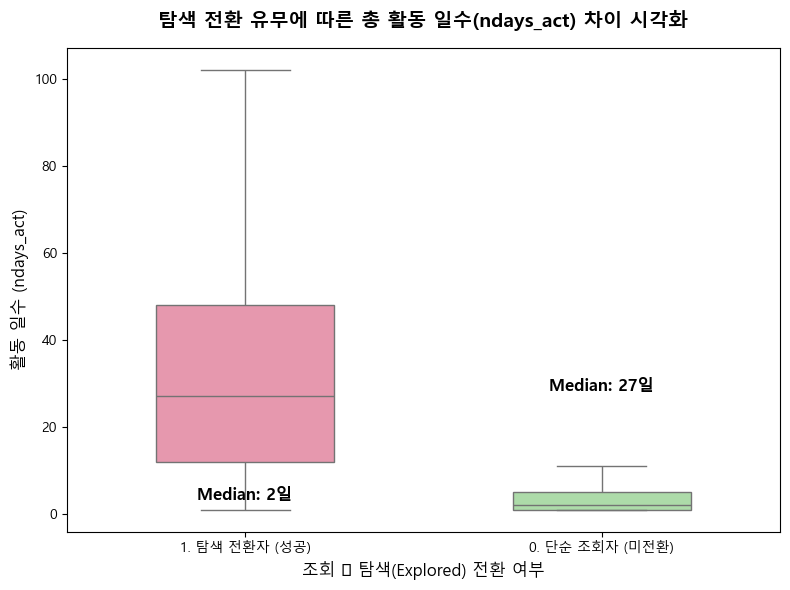

In [11]:
# 1. 시각화를 위한 데이터 준비 (viewed == 1 인원만)
plot_df = df[df['viewed'] == 1].copy()

# 보기 좋게 라벨 달기
plot_df['explored_label'] = plot_df['explored'].map({
    0: '0. 단순 조회자 (미전환)', 
    1: '1. 탐색 전환자 (성공)'
})

fig, ax = plt.subplots(figsize=(8, 6))

# 2. 박스 플롯 시각화 (이상치 제거로 찌그러짐 방지)
sns.boxplot(
    data=plot_df, 
    x='explored_label', 
    y='ndays_act', 
    palette=['#f38ba8', '#a6e3a1'],  # 붉은색(실패) vs 녹색(성공)
    showfliers=False,                # 극단적인 출석왕(이상치) 점들을 지워줌
    width=0.5,
    ax=ax
)

# 3. 비모수 검정의 핵심인 '중앙값(Median)'을 차트 위에 숫자로 찍어주기
medians = plot_df.groupby('explored_label')['ndays_act'].median()
for i, median_val in enumerate(medians):
    ax.text(
        i, median_val + 0.3,             # 박스 중앙값 선에서 살짝 위에 표기
        f'Median: {median_val:.0f}일', 
        ha='center', va='bottom', 
        fontweight='bold', color='black', fontsize=12
    )

# 4. 축과 타이틀 디자인 설정
ax.set_title('탐색 전환 유무에 따른 총 활동 일수(ndays_act) 차이 시각화', fontweight='bold', fontsize=14, pad=15)
ax.set_xlabel('조회 👉 탐색(Explored) 전환 여부', fontsize=12)
ax.set_ylabel('활동 일수 (ndays_act)', fontsize=12)

plt.tight_layout()
plt.show()


- 각 집단의 분포가 시각적으로도 매우 다른 분포를 보인다

### course id 별 전환율 통계검정

In [13]:
from scipy.stats import chi2_contingency

# 1. 대상 그룹 분리: 조회를 한 번이라도 한 사람(viewed == 1) 한정 
viewed_df = df[df['viewed'] == 1].copy()

# 2. 분할표(Contingency Table) 작성
# (각 course_id 마다 탐색 전환(1) 성공자와 미전환(0) 실패자의 인원수 표 생성)
contingency_table = pd.crosstab(viewed_df['course_id'], viewed_df['explored'])

# 3. 카이제곱 독립성 검정 
# (H0: course_id와 전환율은 상관없이 똑같다. / H1: course_id별로 전환율이 유의미하게 튄다.)
chi2, p_val, dof, expected = chi2_contingency(contingency_table)

print("\n■ 카이제곱(Chi-Square) 통계 검정 결과 ■")
print(f"📈 카이제곱 통계량: {chi2:.2f}")
print(f"📉 P-value (유의확률): {p_val:.5e}")

if p_val < 0.05:
    print("👉 결론: 통계적으로 매우 유의미합니다! 어느 '코스(과목)'를 선택했느냐에 따라 탐색(Explored) 전환율이 통계적으로 확실히 다릅니다.")
else:
    print("👉 결론: 코스별 전환율 패턴 양상에 큰 차이가 없습니다.")

print("-" * 55)

# 4. 실질적 차이 크기를 보는 피살기: 크래머 V (Cramer's V) 
# (0에 가까우면 차이 없음, 1에 가까우면 과목이 전환율을 100% 지배함)
n = contingency_table.sum().sum()
min_dim = min(contingency_table.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))

print(f"📊 실무적 효과 크기(Cramer's V): {cramers_v:.3f}")
if cramers_v >= 0.5:
    print("  👉 [효과 큼] 각 과목의 난이도, 강사, 퀄리티 등의 편차가 전환율을 '매우 강력하게' 뒤흔들고 있습니다.")
elif cramers_v >= 0.3:
    print("  👉 [효과 중간] 과목의 종류가 수강생들의 다음 단계 전환 여부에 '적당히 꽤 높은' 연관성을 줍니다.")
elif cramers_v >= 0.1:
    print("  👉 [효과 약함] 통계적으로 차이는 증명되었지만, 실무적으로 봤을 때 완전히 '강한' 편차 수준은 아닙니다.")
else:
    print("  👉 [효과 미미함] 코스 간 차이가 있긴 하지만, 사실상 신경 쓸 변화가 아닙니다. 다른 요인을 찾아봐야 합니다.")



■ 카이제곱(Chi-Square) 통계 검정 결과 ■
📈 카이제곱 통계량: 9789.51
📉 P-value (유의확률): 0.00000e+00
👉 결론: 통계적으로 매우 유의미합니다! 어느 '코스(과목)'를 선택했느냐에 따라 탐색(Explored) 전환율이 통계적으로 확실히 다릅니다.
-------------------------------------------------------
📊 실무적 효과 크기(Cramer's V): 0.173
  👉 [효과 약함] 통계적으로 차이는 증명되었지만, 실무적으로 봤을 때 완전히 '강한' 편차 수준은 아닙니다.


- course id 별 통계검정 결과
  - 통계적으로 유의하다.
  - 하지만 그 효과크기가 작아 실무적으로 그 영향이 유의미하다고 보기 어렵다.

## nevents & explored 전환율 통계검정
- 상관계수 0.41

In [14]:
# 1. 대상 그룹 분리: 조회를 한 번이라도 한 사람(viewed == 1) 중 결측치 제거
group_0 = df[(df['viewed'] == 1) & (df['explored'] == 0)]['nevents'].dropna()
group_1 = df[(df['viewed'] == 1) & (df['explored'] == 1)]['nevents'].dropna()

# --- 기술 통계 (평균과 중앙값 차이 직관적 확인) ---
print(f"[단순 조회자(0)] 평균: {group_0.mean():.1f}일 | 중앙값: {group_0.median():.0f}일 | 총 {len(group_0):,}명")
print(f"[탐색 전환자(1)] 평균: {group_1.mean():.1f}일 | 중앙값: {group_1.median():.0f}일 | 총 {len(group_1):,}명")

# 2. 비모수 검정: Mann-Whitney U test (탐색집단의 활동일수가 '더 큰가?')
# 💡 여기서 반환되는 stat 변수는 group_1을 기준으로 산출된 U 통계량(U1)입니다.
stat, p_val = stats.mannwhitneyu(group_1, group_0, alternative='greater')

print(f"\n📈 Mann-Whitney U 통계량: {stat}")
print(f"📉 P-value (유의확률): {p_val:.5e}")

if p_val < 0.05:
    print("\n👉 [결론 도출] 통계적으로 매우 유의미합니다! (p < 0.05)")
    print("탐색 집단(Explore=1)으로 전환된 사람들의 플랫폼 '활동 일수(nevents)'가 유의미하게 더 깁니다.")
else:
    print("\n👉 [결론 도출] 통계적으로 유의미한 차이가 없습니다.")


# 3. 비모수 환경에 완벽하게 호환되는 효과 크기: Rank-Biserial Correlation (r_rb) 산출
n1 = len(group_1)
n0 = len(group_0)

# 공식: r_rb = (2 * U1) / (n1 * n0) - 1
# 결과값은 -1 ~ 1 사이로 도출되며, 양수면 group_1(탐색 전환자)의 순위가 더 높음을 의미합니다.
r_rb = (2 * stat) / (n1 * n0) - 1
abs_r = abs(r_rb)

print(f"\n📊 비모수적 효과 크기(Rank-Biserial Correlation): {r_rb:.3f}")

# 효과 크기 가이드라인 (비모수 상관계수 r 기준: 0.1=Small, 0.3=Medium, 0.5=Large)
if abs_r >= 0.5:
    print("   👉 효과 크기가 '매우 큼(Large)' 수준입니다.")
elif abs_r >= 0.3:
    print("   👉 효과 크기가 '중간(Medium)' 수준입니다.")
elif abs_r >= 0.1:
    print("   👉 효과 크기가 '작음(Small)' 수준입니다.")
else:
    print("   👉 효과 크기가 '미미함(Trivial)' 수준입니다.")


[단순 조회자(0)] 평균: 221.1일 | 중앙값: 49일 | 총 285,970명
[탐색 전환자(1)] 평균: 3372.8일 | 중앙값: 2127일 | 총 37,584명

📈 Mann-Whitney U 통계량: 9368999248.5
📉 P-value (유의확률): 0.00000e+00

👉 [결론 도출] 통계적으로 매우 유의미합니다! (p < 0.05)
탐색 집단(Explore=1)으로 전환된 사람들의 플랫폼 '활동 일수(nevents)'가 유의미하게 더 깁니다.

📊 비모수적 효과 크기(Rank-Biserial Correlation): 0.743
   👉 효과 크기가 '매우 큼(Large)' 수준입니다.


- nevents의 경우에도 유의하고, 효과크기가 크다.

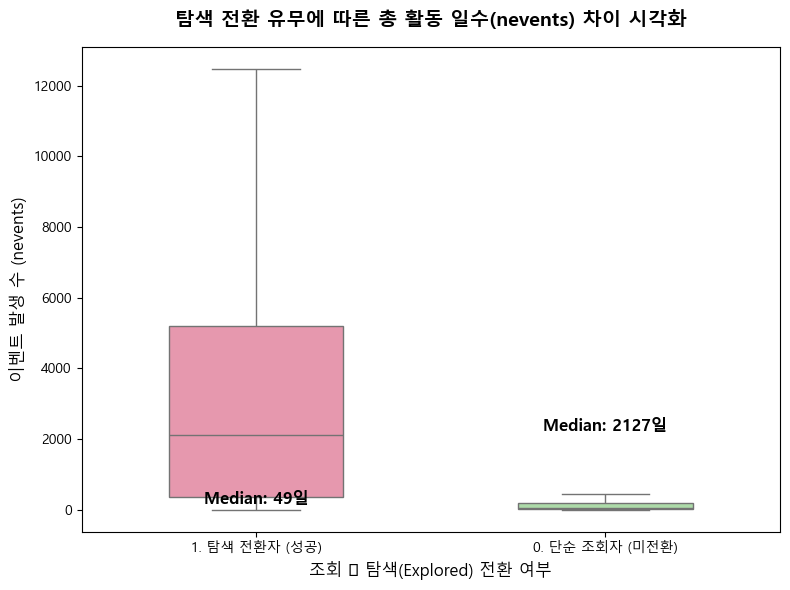

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 시각화를 위한 데이터 준비 (viewed == 1 인원만)
plot_df = df[df['viewed'] == 1].copy()

# 보기 좋게 라벨 달기
plot_df['explored_label'] = plot_df['explored'].map({
    0: '0. 단순 조회자 (미전환)', 
    1: '1. 탐색 전환자 (성공)'
})

fig, ax = plt.subplots(figsize=(8, 6))

# 2. 박스 플롯 시각화 (이상치 제거로 찌그러짐 방지)
sns.boxplot(
    data=plot_df, 
    x='explored_label', 
    y='nevents', 
    palette=['#f38ba8', '#a6e3a1'],  # 붉은색(실패) vs 녹색(성공)
    showfliers=False,                # 극단적인 출석왕(이상치) 점들을 지워줌
    width=0.5,
    ax=ax
)

# 3. 비모수 검정의 핵심인 '중앙값(Median)'을 차트 위에 숫자로 찍어주기
medians = plot_df.groupby('explored_label')['nevents'].median()
for i, median_val in enumerate(medians):
    ax.text(
        i, median_val + 0.3,             # 박스 중앙값 선에서 살짝 위에 표기
        f'Median: {median_val:.0f}일', 
        ha='center', va='bottom', 
        fontweight='bold', color='black', fontsize=12
    )

# 4. 축과 타이틀 디자인 설정
ax.set_title('탐색 전환 유무에 따른 총 활동 일수(nevents) 차이 시각화', fontweight='bold', fontsize=14, pad=15)
ax.set_xlabel('조회 👉 탐색(Explored) 전환 여부', fontsize=12)
ax.set_ylabel('이벤트 발생 수 (nevents)', fontsize=12)

plt.tight_layout()
plt.show()


- boxplot을 통해 두 집단의 분포가 다른 모습을 볼 수 있다.

## KPI: registered -> viewed 전환율

- 분석 간 성별 o(other) 제거
    - 인구 8명으로, 두 집단으로 분리 시 각 기대빈도 수가 5를 넘기지 못해 코크란 규칙 위배.
    - 유의미한 통계 검정이 불가능한 데이터

- 코크란 규칙
- 각 컬럼의 기대빈도 점검

In [21]:
print(f"[전처리] gender='o' 제외 후 분석 대상: {len(df_analysis):,}명 (제외된 행: {len(df) - len(df_analysis):,}명)\n")

print("■ 카이제곱 검정 '기대 빈도(Expected Frequency) 5 이상' 필수 조건 팩트체크 ■\n")

# ✅ 분석 전용 데이터프레임 생성: gender == 'o' 행 제외 (원본 df는 보존)
df_analysis = df[df['gender'] != 'o'].copy()

cat_vars = ['gender', 'LoE_DI', 'age_group', 'final_cc_cname_DI'] 

for var in cat_vars:
    # 1. df_analysis 기준으로 결측치 임시 제거 후 원본 교차표 생성
    temp_df = df_analysis[[var, 'viewed']].dropna()
    crosstab = pd.crosstab(temp_df[var], temp_df['viewed'])
    
    chi2, p_val, dof, expected = stats.chi2_contingency(crosstab)
    
    print(f"[{var} 집단의 관측 전제조건(기대 빈도) 검사]")
    
    expected_df = pd.DataFrame(
        expected, 
        index=crosstab.index, 
        columns=['View=0 (기대 인원)', 'View=1 (기대 인원)']
    ).round(1)
    
    display(expected_df)
    
    invalid_cells = (expected < 5).sum()
    total_cells = expected.size
    
    print(f"👉 전체 {total_cells}개의 칸(Cell) 중, '5명 미만'인 칸 개수: {invalid_cells}개")
    
    if invalid_cells > 0:
        print(f"🚨 [경고] {var} 검정 무효! 기대 빈도가 부족하여 Fisher's Exact Test로 대체해야 합니다.\n")
    else:
        print(f"✅ [안전 통과] 5명 미만인 칸이 단 하나도 없어 통계 검정에 흠결이 없습니다!\n")
        
    print("-" * 65 + "\n")


[전처리] gender='o' 제외 후 분석 대상: 533,985명 (제외된 행: 8명)

■ 카이제곱 검정 '기대 빈도(Expected Frequency) 5 이상' 필수 조건 팩트체크 ■

[gender 집단의 관측 전제조건(기대 빈도) 검사]


,View=0 (기대 인원),View=1 (기대 인원)
gender,,
f,47201.7000,73611.3000
m,132958.8000,207350.2000
unknown,28467.6000,44395.4000


👉 전체 6개의 칸(Cell) 중, '5명 미만'인 칸 개수: 0개
✅ [안전 통과] 5명 미만인 칸이 단 하나도 없어 통계 검정에 흠결이 없습니다!

-----------------------------------------------------------------

[LoE_DI 집단의 관측 전제조건(기대 빈도) 검사]


,View=0 (기대 인원),View=1 (기대 인원)
LoE_DI,,
Bachelor's,71665.7000,111763.3000
Doctorate,4555.2000,7103.8000
Less than Secondary,4363.7000,6805.3000
Master's,39286.5000,61267.5000
Secondary,54432.7000,84888.3000
unknown,34324.2000,53528.8000


👉 전체 12개의 칸(Cell) 중, '5명 미만'인 칸 개수: 0개
✅ [안전 통과] 5명 미만인 칸이 단 하나도 없어 통계 검정에 흠결이 없습니다!

-----------------------------------------------------------------

[age_group 집단의 관측 전제조건(기대 빈도) 검사]


,View=0 (기대 인원),View=1 (기대 인원)
age_group,,
20s,105324.9000,164255.1000
30s,33706.1000,52564.9000
40s,9947.6000,15513.4000
50s,4227.0000,6592.0000
60_plus,1839.8000,2869.2000
under_20,21917.1000,34179.9000
unknown,31665.5000,49382.5000


👉 전체 14개의 칸(Cell) 중, '5명 미만'인 칸 개수: 0개
✅ [안전 통과] 5명 미만인 칸이 단 하나도 없어 통계 검정에 흠결이 없습니다!

-----------------------------------------------------------------

[final_cc_cname_DI 집단의 관측 전제조건(기대 빈도) 검사]


,View=0 (기대 인원),View=1 (기대 인원)
final_cc_cname_DI,,
Australia,2141.4000,3339.6000
Bangladesh,1023.2000,1595.8000
Brazil,6242.6000,9735.4000
Canada,4143.4000,6461.6000
China,1859.7000,2900.3000
Colombia,1670.6000,2605.4000
Egypt,3219.8000,5021.2000
France,1581.9000,2467.1000
Germany,2822.0000,4401.0000


👉 전체 68개의 칸(Cell) 중, '5명 미만'인 칸 개수: 0개
✅ [안전 통과] 5명 미만인 칸이 단 하나도 없어 통계 검정에 흠결이 없습니다!

-----------------------------------------------------------------



In [23]:
import statsmodels.api as sm
from statsmodels.stats.proportion import proportion_confint

# ※ df_analysis는 이전 셀에서 gender='o' 제외하여 이미 정의된 상태

# =========================================================
# [1단계] 전체 전환율 베이스라인 및 95% 신뢰구간(CI) 확인
# =========================================================
print("■ [1단계] 기초 체력 확인 (Baseline & 95% CI) ■")
total_users = len(df_analysis)
viewed_users = df_analysis['viewed'].sum()
overall_rate = viewed_users / total_users

ci_low, ci_upp = proportion_confint(count=viewed_users, nobs=total_users, alpha=0.05, method='normal')

print(f"- 분석 대상 가입자(gender='o' 제외): {total_users:,}명 | 실제 강의 열람: {viewed_users:,}명")
print(f"- 평균 '가입 ➔ 조회' 전환율: {overall_rate * 100:.2f}%")
print(f"- 95% 신뢰구간(CI): {ci_low * 100:.2f}% ~ {ci_upp * 100:.2f}%\n")
print("-" * 65 + "\n")


# =========================================================
# [2단계] 카이제곱(Chi-square): 그룹별 단순 전환율 차이 존재 여부
# =========================================================
print("■ [2단계] 후보 변수 예선전 (카이제곱 검정: P-value 확인) ■")
cat_vars = ['gender', 'LoE_DI', 'age_group', 'final_cc_cname_DI']
chi2_results = {}

for var in cat_vars:
    temp_df = df_analysis[[var, 'viewed']].dropna()
    crosstab = pd.crosstab(temp_df[var], temp_df['viewed'])

    chi2, p_val, dof, expected = stats.chi2_contingency(crosstab)
    chi2_results[var] = {'chi2': chi2, 'p_val': p_val, 'crosstab': crosstab}

    print(f"- [{var}] 집단 간 전환율 차이 유의성(P-value): {p_val:.5e}")
print("-" * 65 + "\n")


# =========================================================
# [3단계] 로지스틱 회귀: 어떤 변수가 '독립적'으로 유의한지 본선 검증
# =========================================================
print("■ [3단계] 진짜 원인 색출 (로지스틱 회귀: 독립적 P-value 확인) ■")
model_df = df_analysis[['viewed', 'age', 'gender', 'LoE_DI']].dropna().copy()
model_df['is_male'] = (model_df['gender'] == 'm').astype(int)
model_df['is_high_edu'] = model_df['LoE_DI'].isin(["Bachelor's", "Master's", "Doctorate"]).astype(int)

Y = model_df['viewed']
X = model_df[['age', 'is_male', 'is_high_edu']]
X = sm.add_constant(X)

logit_model = sm.Logit(Y, X).fit(disp=False)

print(f"- 유사 결정계수(Pseudo R-squ): {logit_model.prsquared:.4f}")
print("- 각 변수별 독립적 유의성 (다른 변수를 고정했을 때도 유의미한가?):")
for var, p_val in logit_model.pvalues.items():
    if var == 'const': continue
    print(f"  * {var} 의 P-value = {p_val:.5e}")
print("-" * 65 + "\n")


# =========================================================
# [4단계] 효과 크기 보고: 비즈니스적으로 '쓸모'가 있는가?
# =========================================================
print("■ [4단계] 비즈니스 임팩트 판단 (실질적 효과 크기 산출) ■")

print("\n1) 범주형 변수의 차이 규모 (Cramer's V 기준)")
for var, res in chi2_results.items():
    n = res['crosstab'].sum().sum()
    min_dim = min(res['crosstab'].shape) - 1
    cramers_v = np.sqrt(res['chi2'] / (n * min_dim))

    if cramers_v >= 0.5: effect = "매우 큼 🔥"
    elif cramers_v >= 0.3: effect = "중간 🔸"
    elif cramers_v >= 0.1: effect = "약함 🔹"
    else: effect = "미미함 💧 (통계적으로는 차이나지만 실무 임팩트 없음)"

    print(f"  - [{var}] Cramer's V: {cramers_v:.3f} 👉 실무적 체감 규모: {effect}")

print("\n2) 다중 변수의 순수 타격량 (Odds Ratio 기준)")
odds_ratios = np.exp(logit_model.params)
for var, or_val in odds_ratios.items():
    if var == 'const': continue
    print(f"  - [{var}] Odds Ratio: {or_val:.3f}배 👉 (1.0에 가까울수록 현실 타격감 없음)")


■ [1단계] 기초 체력 확인 (Baseline & 95% CI) ■
- 분석 대상 가입자(gender='o' 제외): 533,985명 | 실제 강의 열람: 325,357명
- 평균 '가입 ➔ 조회' 전환율: 60.93%
- 95% 신뢰구간(CI): 60.80% ~ 61.06%

-----------------------------------------------------------------

■ [2단계] 후보 변수 예선전 (카이제곱 검정: P-value 확인) ■
- [gender] 집단 간 전환율 차이 유의성(P-value): 0.00000e+00
- [LoE_DI] 집단 간 전환율 차이 유의성(P-value): 0.00000e+00
- [age_group] 집단 간 전환율 차이 유의성(P-value): 0.00000e+00
- [final_cc_cname_DI] 집단 간 전환율 차이 유의성(P-value): 0.00000e+00
-----------------------------------------------------------------

■ [3단계] 진짜 원인 색출 (로지스틱 회귀: 독립적 P-value 확인) ■
- 유사 결정계수(Pseudo R-squ): 0.0018
- 각 변수별 독립적 유의성 (다른 변수를 고정했을 때도 유의미한가?):
  * age 의 P-value = 1.16278e-11
  * is_male 의 P-value = 3.48991e-201
  * is_high_edu 의 P-value = 1.36965e-09
-----------------------------------------------------------------

■ [4단계] 비즈니스 임팩트 판단 (실질적 효과 크기 산출) ■

1) 범주형 변수의 차이 규모 (Cramer's V 기준)
  - [gender] Cramer's V: 0.082 👉 실무적 체감 규모: 미미함 💧 (통계적으로는 차이나지만 실무 임팩트 없음)
  - [LoE_DI] Cram

[1단계] "우리가 설명해야 할 현상이 뭔가?"    
         → 전체 전환율 60.93% 확정 (기준점 설정)  
              ↓     
[2단계] "이 전환율의 차이를 만드는 범주형 변수가 있는가?"   
         → 카이제곱으로 각 변수의 연관성 존재 여부 확인     
              ↓     
[3단계] "2단계에서 나온 변수들이 서로 독립적으로도 유의한가?"    
         → 로지스틱 회귀로 교란 변수 제거 후 순수 효과 검증      
              ↓     
[4단계] "통계적으로 유의미한 것들이 실무에서도 의미있는 차이인가?"    
         → 효과 크기(Cramer's V, OR)로 비즈니스 판단   


- 로지스틱 회귀 사용 근거
  - 교란 변수 통제

카이제곱의 '성별과 학력이 서로 상관되어 있으면, 학력의 효과가 성별의 효과처럼 보이는 착시가 발생할 수 있다'는 한계를 극복하기 위해 로지스틱 회귀 차용
- 결과 해석
  - 모든 컬럼이 유의하게 작용하지만, 표본 수에 의해 작은 차이도 유의하게 잡은 것.
  - 다만, 국가 컬럼의 경우 효과크기가 나타남
  - 해당 컬럼에 대해 어떤 분포를 나타내는지 파악

In [25]:
print("■ 🌍 국가별 '가입 ➔ 조회(열람)' 전환율 랭킹 ■\n")

# 1. 국가(final_cc_cname_DI) 단위로 총 가입자 및 실제 조회자 집계
country_stats = df.groupby('final_cc_cname_DI')['viewed'].agg(
    total_registered='size',   # 전체 가입자 수 (모수)
    total_viewed='sum'         # 실제 조회(1)를 한 사람 수
)

# 2. 직관적인 퍼센트(%) 전환율 계산
country_stats['view_rate(%)'] = (country_stats['total_viewed'] / country_stats['total_registered']) * 100

# 3. 통계적 노이즈 제거: 가입자가 1,000명 미만인 국가는 순위권에서 제외 (필수)
country_stats = country_stats[country_stats['total_registered'] >= 1000]

# 4. 전환율이 높은 국가부터 내림차순 정렬
country_stats = country_stats.sort_values(by='view_rate(%)', ascending=False)

# 5. 보기 좋게 출력
display(country_stats.round(1))


■ 🌍 국가별 '가입 ➔ 조회(열람)' 전환율 랭킹 ■



,total_registered,total_viewed,view_rate(%)
final_cc_cname_DI,,,
Poland,4697,3919,83.4000
Spain,8741,6628,75.8000
Germany,7223,5398,74.7000
Japan,2126,1581,74.4000
Greece,4464,3284,73.6000
Other Europe,35434,26021,73.4000
Mexico,4946,3585,72.5000
Ukraine,3487,2514,72.1000
Colombia,4276,3055,71.4000


- 확인 결과 Unknown/Other의 전환율이 5%로 다른 국가에 비해 매우 낮음을 확인
- Unknown/Other: VPN 우회 로그인? Bot/Spam? 뭔가 심각하게 이상한 집단임    

윤범님 의견: 교육적 목적에서 해당 인원들을 무조건적으로 제한하는 것은 위험할 수 있다!   
- Unknown/Other를 제외하고 분석한 경우 효과크기가 급락하는 모습이 보인다.   
- 해당 국가 분류 하나가 효과크기를 끌어올림     
- 다른 국가들 끼리는 유의미한 분류 효과가 없을 수 있다!     

In [26]:
# 1. Unknown/Other 포함 vs 제외 비교
print("■ Unknown/Other 제외 여부에 따른 Cramer's V 비교 ■\n")

for label, filter_cond in [
    ("포함 (원본)", df_analysis['final_cc_cname_DI'] != '__제외없음__'), 
    ("제외 (Unknown/Other 제거)", df_analysis['final_cc_cname_DI'] != 'Unknown/Other')
]:
    temp = df_analysis[filter_cond][['final_cc_cname_DI', 'viewed']].dropna()
    crosstab = pd.crosstab(temp['final_cc_cname_DI'], temp['viewed'])
    chi2, p_val, dof, expected = stats.chi2_contingency(crosstab)

    n = crosstab.sum().sum()
    min_dim = min(crosstab.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))

    print(f"[{label}]")
    print(f"  분석 대상 N: {n:,}명")
    print(f"  Cramer's V: {cramers_v:.3f}")
    print(f"  P-value: {p_val:.5e}\n")


■ Unknown/Other 제외 여부에 따른 Cramer's V 비교 ■

[포함 (원본)]
  분석 대상 N: 533,985명
  Cramer's V: 0.375
  P-value: 0.00000e+00

[제외 (Unknown/Other 제거)]
  분석 대상 N: 484,786명
  Cramer's V: 0.094
  P-value: 0.00000e+00



Unknown/Other 제거 시 다른 변수 간 유의미한 분포 차이가 없음을 확인

Unknown/Other 집단: 49,202명 (전체의 9.2%)



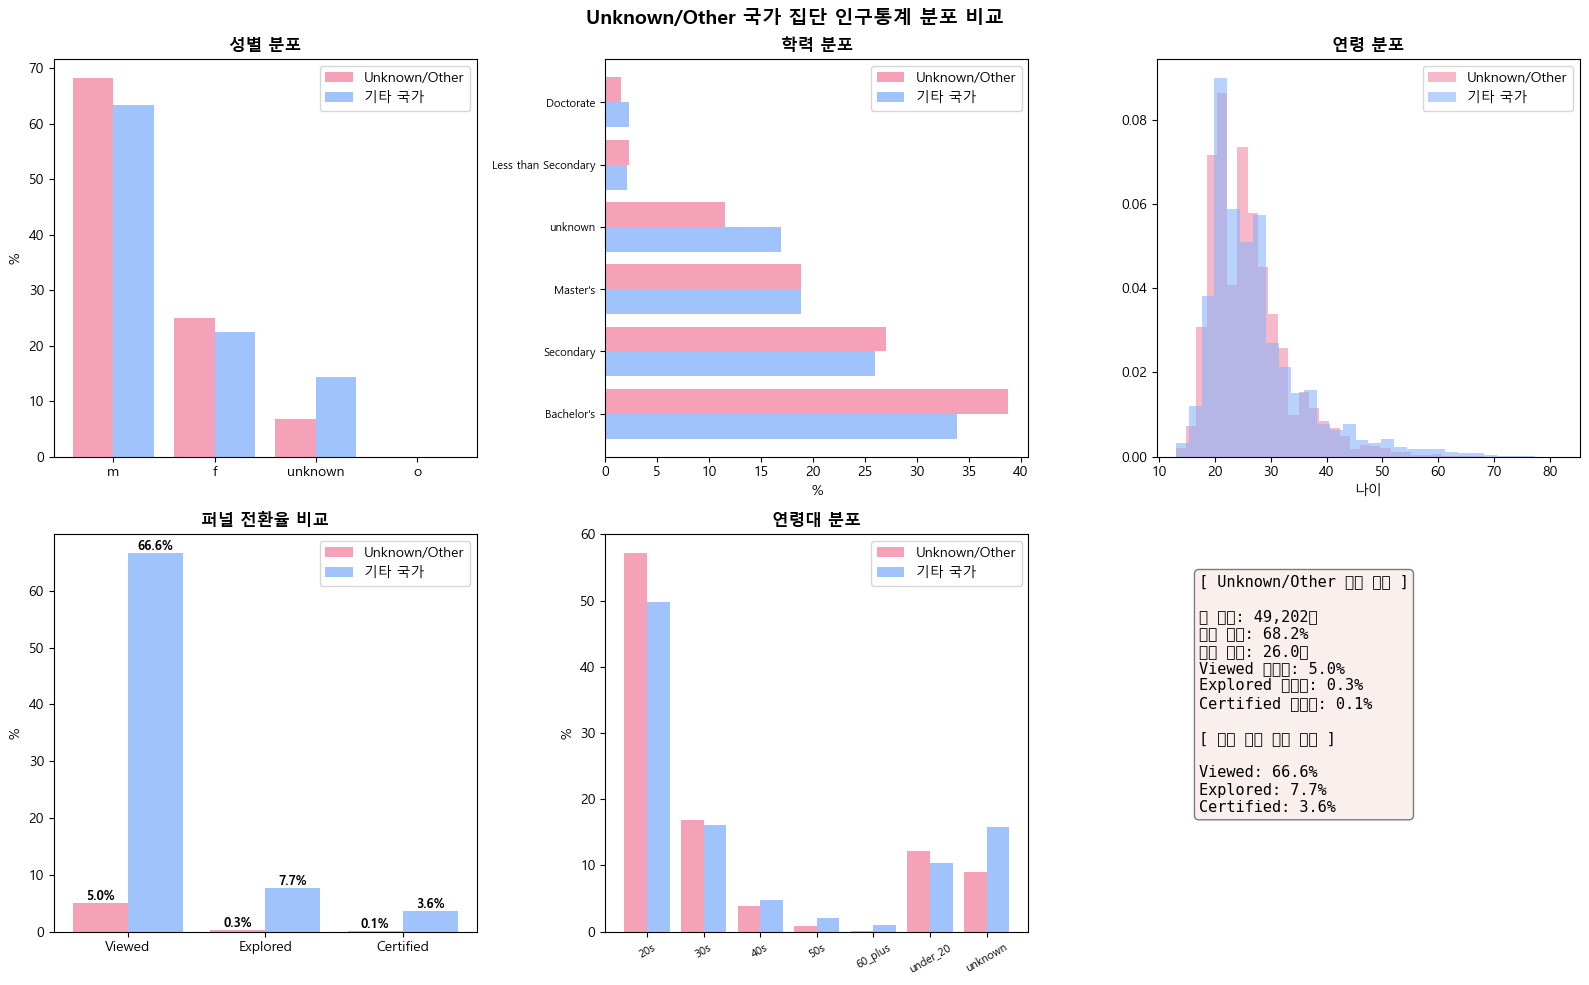

[ Unknown/Other 집단 요약 ]


총 인원: 49,202명

남성 비율: 68.2%

평균 나이: 26.0세

Viewed 전환율: 5.0%

Explored 전환율: 0.3%

Certified 전환율: 0.1%


[ 기타 국가 집단 대비 ]


Viewed: 66.6%

Explored: 7.7%

Certified: 3.6%


In [41]:
# Unknown/Other 집단 분리
unknown_df = df[df['final_cc_cname_DI'] == 'Unknown/Other'].copy()
known_df = df[df['final_cc_cname_DI'] != 'Unknown/Other'].copy()

print(f"Unknown/Other 집단: {len(unknown_df):,}명 (전체의 {len(unknown_df)/len(df)*100:.1f}%)\n")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Unknown/Other 국가 집단 인구통계 분포 비교', fontweight='bold', fontsize=14)

# 1. 성별 분포
gender_unk = unknown_df['gender'].value_counts(normalize=True) * 100
gender_kno = known_df['gender'].value_counts(normalize=True) * 100
x = range(len(gender_unk))
axes[0,0].bar([i-0.2 for i in x], gender_unk.values, 0.4, label='Unknown/Other', color='#f38ba8', alpha=0.8)
axes[0,0].bar([i+0.2 for i in x], gender_kno.reindex(gender_unk.index).values, 0.4, label='기타 국가', color='#89b4fa', alpha=0.8)
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(gender_unk.index)
axes[0,0].set_title('성별 분포', fontweight='bold'); axes[0,0].set_ylabel('%')
axes[0,0].legend()

# 2. 학력 분포
loe_unk = unknown_df['LoE_DI'].value_counts(normalize=True) * 100
loe_kno = known_df['LoE_DI'].value_counts(normalize=True) * 100
all_cats = loe_unk.index
axes[0,1].barh([i+0.2 for i in range(len(all_cats))], loe_unk.values, 0.4, label='Unknown/Other', color='#f38ba8', alpha=0.8)
axes[0,1].barh([i-0.2 for i in range(len(all_cats))], loe_kno.reindex(all_cats).fillna(0).values, 0.4, label='기타 국가', color='#89b4fa', alpha=0.8)
axes[0,1].set_yticks(range(len(all_cats))); axes[0,1].set_yticklabels(all_cats, fontsize=8)
axes[0,1].set_title('학력 분포', fontweight='bold'); axes[0,1].set_xlabel('%')
axes[0,1].legend()

# 3. 연령 분포 (히스토그램)
axes[0,2].hist(unknown_df['age'].dropna(), bins=30, alpha=0.6, label='Unknown/Other', color='#f38ba8', density=True)
axes[0,2].hist(known_df['age'].dropna(), bins=30, alpha=0.6, label='기타 국가', color='#89b4fa', density=True)
axes[0,2].set_title('연령 분포', fontweight='bold'); axes[0,2].set_xlabel('나이')
axes[0,2].legend()

# 4. 퍼널 전환율 비교
metrics = ['viewed', 'explored', 'certified']
unk_rates = [unknown_df[m].mean()*100 for m in metrics]
kno_rates = [known_df[m].mean()*100 for m in metrics]
x2 = range(len(metrics))
axes[1,0].bar([i-0.2 for i in x2], unk_rates, 0.4, label='Unknown/Other', color='#f38ba8', alpha=0.8)
axes[1,0].bar([i+0.2 for i in x2], kno_rates, 0.4, label='기타 국가', color='#89b4fa', alpha=0.8)
for i, (u, k) in enumerate(zip(unk_rates, kno_rates)):
    axes[1,0].text(i-0.2, u+0.5, f'{u:.1f}%', ha='center', fontsize=9, fontweight='bold')
    axes[1,0].text(i+0.2, k+0.5, f'{k:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1,0].set_xticks(x2); axes[1,0].set_xticklabels(['Viewed', 'Explored', 'Certified'])
axes[1,0].set_title('퍼널 전환율 비교', fontweight='bold'); axes[1,0].set_ylabel('%')
axes[1,0].legend()

# 5. 연령대 분포
age_unk = unknown_df['age_group'].value_counts(normalize=True).sort_index() * 100
age_kno = known_df['age_group'].value_counts(normalize=True).reindex(age_unk.index).fillna(0) * 100
axes[1,1].bar([i-0.2 for i in range(len(age_unk))], age_unk.values, 0.4, label='Unknown/Other', color='#f38ba8', alpha=0.8)
axes[1,1].bar([i+0.2 for i in range(len(age_unk))], age_kno.values, 0.4, label='기타 국가', color='#89b4fa', alpha=0.8)
axes[1,1].set_xticks(range(len(age_unk))); axes[1,1].set_xticklabels(age_unk.index, rotation=30, fontsize=8)
axes[1,1].set_title('연령대 분포', fontweight='bold'); axes[1,1].set_ylabel('%')
axes[1,1].legend()

# 6. 기술 통계 요약 텍스트
axes[1,2].axis('off')
summary_text = (
    f"[ Unknown/Other 집단 요약 ]\n\n"
    f"총 인원: {len(unknown_df):,}명\n"
    f"남성 비율: {(unknown_df['gender']=='m').mean()*100:.1f}%\n"
    f"평균 나이: {unknown_df['age'].mean():.1f}세\n"
    f"Viewed 전환율: {unknown_df['viewed'].mean()*100:.1f}%\n"
    f"Explored 전환율: {unknown_df['explored'].mean()*100:.1f}%\n"
    f"Certified 전환율: {unknown_df['certified'].mean()*100:.1f}%\n\n"
    f"[ 기타 국가 집단 대비 ]\n\n"
    f"Viewed: {known_df['viewed'].mean()*100:.1f}%\n"
    f"Explored: {known_df['explored'].mean()*100:.1f}%\n"
    f"Certified: {known_df['certified'].mean()*100:.1f}%"
)
axes[1,2].text(0.1, 0.9, summary_text, transform=axes[1,2].transAxes,
               fontsize=11, va='top', fontfamily='monospace',
               bbox=dict(boxstyle='round', facecolor='#f5e0dc', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"[ Unknown/Other 집단 요약 ]\n\n")
print(f"총 인원: {len(unknown_df):,}명\n")
print(f"남성 비율: {(unknown_df['gender']=='m').mean()*100:.1f}%\n")
print(f"평균 나이: {unknown_df['age'].mean():.1f}세\n")
print(f"Viewed 전환율: {unknown_df['viewed'].mean()*100:.1f}%\n")
print(f"Explored 전환율: {unknown_df['explored'].mean()*100:.1f}%\n")
print(f"Certified 전환율: {unknown_df['certified'].mean()*100:.1f}%\n\n")
print(f"[ 기타 국가 집단 대비 ]\n\n")
print(f"Viewed: {known_df['viewed'].mean()*100:.1f}%\n")
print(f"Explored: {known_df['explored'].mean()*100:.1f}%\n")
print(f"Certified: {known_df['certified'].mean()*100:.1f}%")

인구통계학적 분포는 크게 다르지 않은 모습을 보이지만, 퍼널 전환율에서 극단적으로 큰 차이 발생.
- 해당 컬럼에 대한 자세한 분석 및 조사는 차후 여건에 따라 진행

### exam_flag 변수와 exp 전환율

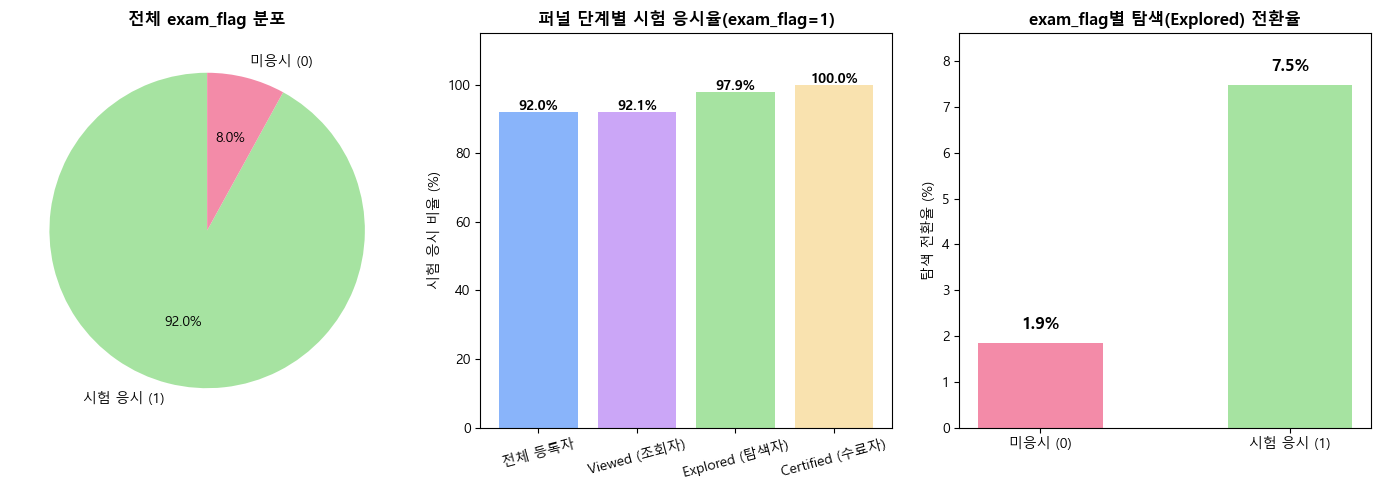


■ exam_flag 기본 현황 ■
- 전체 533,993명 중 시험 응시자(exam_flag=1): 491,268명 (92.0%)
- 미응시자(exam_flag=0): 42,725명 (8.0%)


In [28]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# 1. 전체 exam_flag 분포 (파이차트)
flag_counts = df['exam_flag'].value_counts()
axes[0].pie(
    flag_counts,
    labels=['시험 응시 (1)', '미응시 (0)'],
    autopct='%1.1f%%',
    colors=['#a6e3a1', '#f38ba8'],
    startangle=90
)
axes[0].set_title('전체 exam_flag 분포', fontweight='bold')

# 2. 퍼널 단계별 exam_flag=1 비율
funnel_stages = {
    '전체 등록자': df,
    'Viewed (조회자)': df[df['viewed'] == 1],
    'Explored (탐색자)': df[df['explored'] == 1],
    'Certified (수료자)': df[df['certified'] == 1]
}

stage_names = list(funnel_stages.keys())
exam_rates = [data['exam_flag'].mean() * 100 for data in funnel_stages.values()]

bars = axes[1].bar(stage_names, exam_rates, color=['#89b4fa', '#cba6f7', '#a6e3a1', '#f9e2af'])
for bar, val in zip(bars, exam_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
axes[1].set_title('퍼널 단계별 시험 응시율(exam_flag=1)', fontweight='bold')
axes[1].set_ylabel('시험 응시 비율 (%)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].set_ylim(0, max(exam_rates) * 1.15)

# 3. exam_flag × explored 교차 비율
cross = df.groupby('exam_flag')['explored'].mean() * 100
bars2 = axes[2].bar(['미응시 (0)', '시험 응시 (1)'], cross.values,
                     color=['#f38ba8', '#a6e3a1'], width=0.5)
for bar, val in zip(bars2, cross.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[2].set_title('exam_flag별 탐색(Explored) 전환율', fontweight='bold')
axes[2].set_ylabel('탐색 전환율 (%)')
axes[2].set_ylim(0, max(cross.values) * 1.15)

plt.tight_layout()
plt.show()

# 기술 통계 출력
print("\n■ exam_flag 기본 현황 ■")
print(f"- 전체 {len(df):,}명 중 시험 응시자(exam_flag=1): {flag_counts.get(1,0):,}명 ({flag_counts.get(1,0)/len(df)*100:.1f}%)")
print(f"- 미응시자(exam_flag=0): {flag_counts.get(0,0):,}명 ({flag_counts.get(0,0)/len(df)*100:.1f}%)")


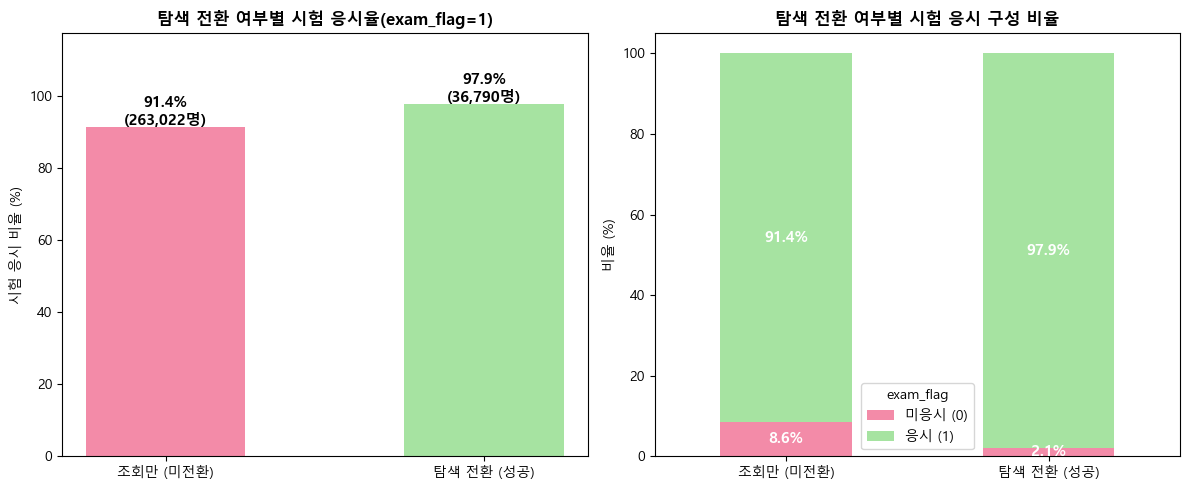


■ 카이제곱 검정 결과 ■
- P-value: 0.00000e+00
- Cramer's V (효과 크기): 0.077

⭐ 탐색 전환 여부와 시험 응시 여부는 통계적으로 유의미하게 연관됩니다!


In [29]:
# 1. viewed 한 사람 기준으로 4개 그룹 생성
viewed_df = df[df['viewed'] == 1].copy()
viewed_df['group'] = '조회만 (미전환)'
viewed_df.loc[viewed_df['explored'] == 1, 'group'] = '탐색 전환 (성공)'

# 2. 그룹별 exam_flag=1 비율
cross = viewed_df.groupby('group')['exam_flag'].agg(['mean', 'sum', 'count']).reset_index()
cross.columns = ['group', 'exam_rate', 'exam_count', 'total']
cross['exam_rate'] *= 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 3. 시험 응시율 비교 막대차트
bars = axes[0].bar(cross['group'], cross['exam_rate'],
                   color=['#f38ba8', '#a6e3a1'], width=0.5)
for bar, row in zip(bars, cross.itertuples()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{row.exam_rate:.1f}%\n({row.exam_count:,}명)',
                 ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('탐색 전환 여부별 시험 응시율(exam_flag=1)', fontweight='bold')
axes[0].set_ylabel('시험 응시 비율 (%)')
axes[0].set_ylim(0, max(cross['exam_rate']) * 1.2)

# 4. 스택 비율 차트 (exam_flag 0/1 구성 비율)
stack_data = viewed_df.groupby(['group', 'exam_flag']).size().unstack(fill_value=0)
stack_pct = stack_data.div(stack_data.sum(axis=1), axis=0) * 100

stack_pct.plot(kind='bar', stacked=True, ax=axes[1],
               color=['#f38ba8', '#a6e3a1'], rot=0, width=0.5)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', label_type='center',
                      fontweight='bold', color='white', fontsize=11)
axes[1].set_title('탐색 전환 여부별 시험 응시 구성 비율', fontweight='bold')
axes[1].set_ylabel('비율 (%)')
axes[1].set_xlabel('')
axes[1].legend(['미응시 (0)', '응시 (1)'], title='exam_flag')

plt.tight_layout()
plt.show()

# 5. 카이제곱 검정 (독립성 검정)
crosstab = pd.crosstab(viewed_df['group'], viewed_df['exam_flag'])
chi2, p_val, dof, expected = stats.chi2_contingency(crosstab)
cramers_v = np.sqrt(chi2 / (crosstab.sum().sum() * (min(crosstab.shape) - 1)))

print("\n■ 카이제곱 검정 결과 ■")
print(f"- P-value: {p_val:.5e}")
print(f"- Cramer's V (효과 크기): {cramers_v:.3f}")
print(f"\n{'⭐ 탐색 전환 여부와 시험 응시 여부는 통계적으로 유의미하게 연관됩니다!' if p_val < 0.05 else '통계적으로 유의미한 차이 없음'}")


유의하지만, 효과크기는 크지 않다

### certified와의 관계는 어떨까?

In [40]:
# 수료 여부와 exam_flag의 관계를 확인해보는 것이 더 흥미로울 수 있음
cross_cert = pd.crosstab(df['exam_flag'], df['certified'])
chi2, p_val, dof, expected = stats.chi2_contingency(cross_cert)
cramers_v_cert = np.sqrt(chi2 / (cross_cert.sum().sum() * (min(cross_cert.shape)-1)))
print(f"exam_flag × certified P-value: {p_val:.5e}")
print(f"exam_flag × certified Cramer's V: {cramers_v_cert:.3f}")


exam_flag × certified P-value: 0.00000e+00
exam_flag × certified Cramer's V: 0.055


시험 응시 여부 자체는 인증률에 큰 영향을 미치지 않음

## High Risk / Low Risk 집단 & Explored 전환율

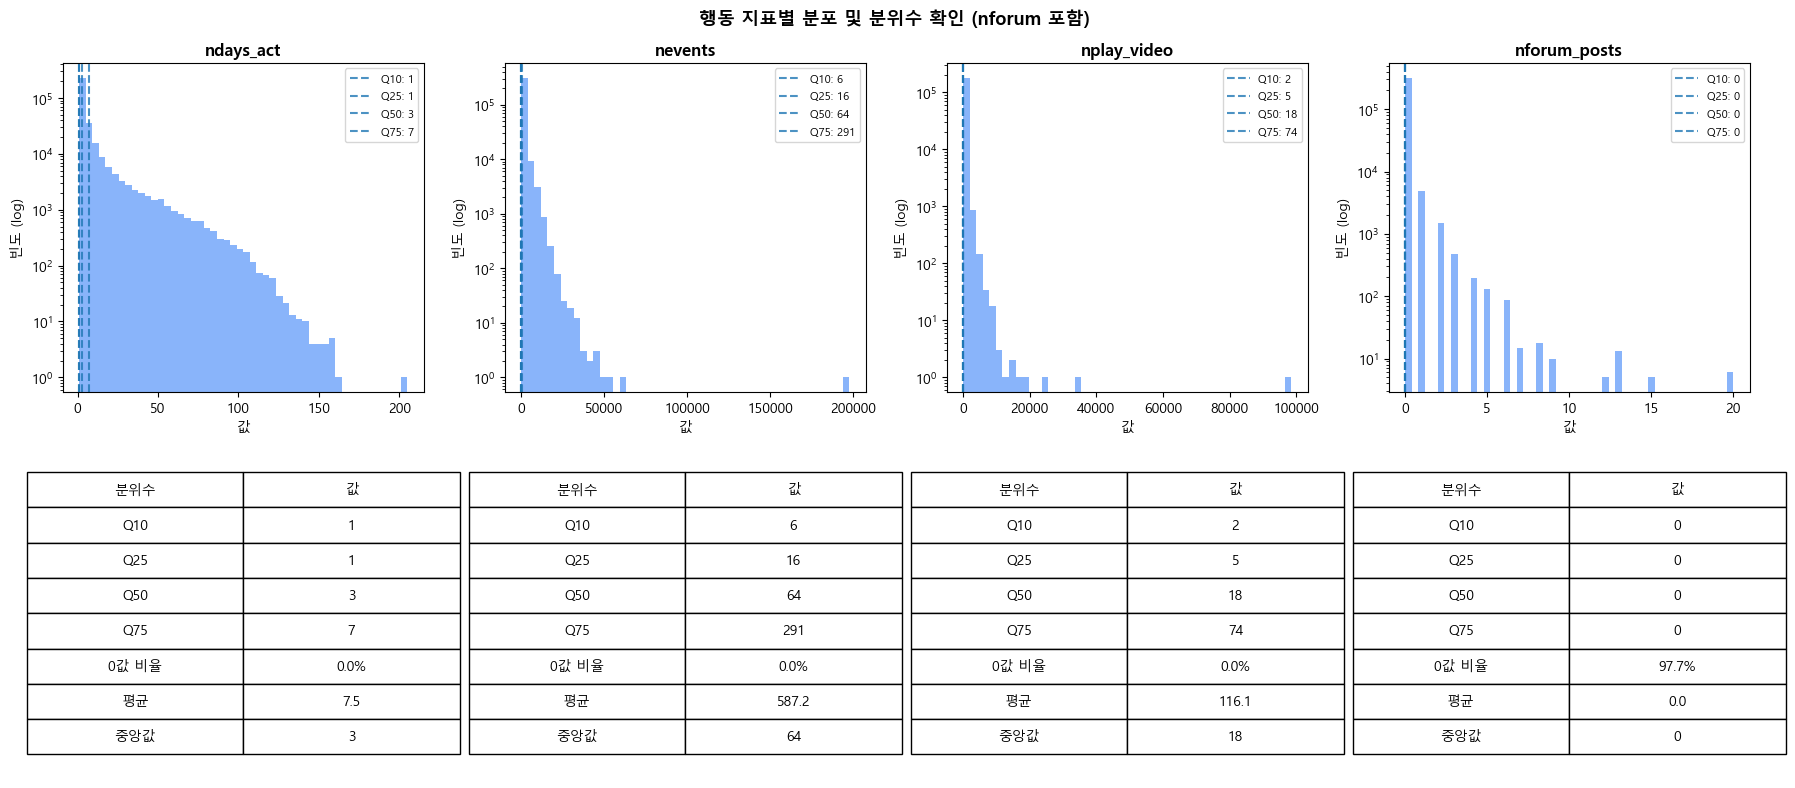

In [42]:
viewed_df = df[df['viewed'] == 1].copy()
cols = ['ndays_act', 'nevents', 'nplay_video', 'nforum_posts']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
quantiles = [0.10, 0.25, 0.50, 0.75]

for i, col in enumerate(cols):
    data = viewed_df[col].dropna()

    axes[0, i].hist(data, bins=50, color='#89b4fa', log=True, edgecolor='none')
    for q in quantiles:
        val = data.quantile(q)
        axes[0, i].axvline(val, linestyle='--', alpha=0.8, label=f'Q{int(q*100)}: {val:.0f}')
    axes[0, i].set_title(col, fontweight='bold')
    axes[0, i].set_xlabel('값')
    axes[0, i].set_ylabel('빈도 (log)')
    axes[0, i].legend(fontsize=8)

    axes[1, i].axis('off')
    q_vals = data.quantile(quantiles).round(1)
    zero_pct = (data == 0).mean() * 100
    table_data = [[f'Q{int(q*100)}', f'{v:.0f}'] for q, v in zip(quantiles, q_vals)] + \
                 [['0값 비율', f'{zero_pct:.1f}%']] + \
                 [['평균', f'{data.mean():.1f}'], ['중앙값', f'{data.median():.0f}']]
    table = axes[1, i].table(cellText=table_data, colLabels=['분위수', '값'],
                              loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.8)

plt.suptitle('행동 지표별 분포 및 분위수 확인 (nforum 포함)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


High Risk 집단 정의를 위한 Quantile 기반 분석
- ndays_act
  - Q25까지 1로 동일한 분포를 보여 추가 탐색 필요
- nevents, nplay_video
  - Q25 사용
- nforum_posts
  - Q75까지 0 동일값 분포. 그에 따라 위험 그룹 조건 0 고정값으로 지정

In [43]:
viewed_df = df[df['viewed'] == 1].copy()

q25 = viewed_df['ndays_act'].quantile(0.25)  # = 1일
q50 = viewed_df['ndays_act'].quantile(0.50)  # = 3일

# Q25 기준으로 분류
viewed_df['risk_q25'] = (viewed_df['ndays_act'] <= q25).astype(int)
# Q50 기준으로 분류
viewed_df['risk_q50'] = (viewed_df['ndays_act'] <= q50).astype(int)

print(f"■ ndays_act 기준값: Q25={q25:.0f}일, Q50={q50:.0f}일\n")

for label, col in [('Q25 기준 (≤1일)', 'risk_q25'), ('Q50 기준 (≤3일)', 'risk_q50')]:
    high = viewed_df[viewed_df[col] == 1]['explored']
    low  = viewed_df[viewed_df[col] == 0]['explored']
    
    high_rate = high.mean() * 100
    low_rate  = low.mean()  * 100
    
    # 카이제곱 검정
    crosstab = pd.crosstab(viewed_df[col], viewed_df['explored'])
    chi2, p_val, dof, expected = stats.chi2_contingency(crosstab)
    cramers_v = np.sqrt(chi2 / (crosstab.sum().sum() * (min(crosstab.shape) - 1)))
    
    print(f"[{label}]")
    print(f"  High Risk 집단 탐색 전환율: {high_rate:.2f}% ({len(high):,}명)")
    print(f"  Low Risk  집단 탐색 전환율: {low_rate:.2f}%  ({len(low):,}명)")
    print(f"  P-value: {p_val:.5e} | Cramer's V: {cramers_v:.3f}")
    print()


■ ndays_act 기준값: Q25=1일, Q50=3일

[Q25 기준 (≤1일)]
  High Risk 집단 탐색 전환율: 1.47% (93,002명)
  Low Risk  집단 탐색 전환율: 15.59%  (232,359명)
  P-value: 0.00000e+00 | Cramer's V: 0.200

[Q50 기준 (≤3일)]
  High Risk 집단 탐색 전환율: 1.83% (188,528명)
  Low Risk  집단 탐색 전환율: 24.95%  (136,833명)
  P-value: 0.00000e+00 | Cramer's V: 0.357



Q50을 기준으로 Risk 집단을 분류하는 것이 분포 차이에 더 유의미한 경향을 보임.

In [44]:
# 각 조건 충족 시 1점씩 부여 → 3점 이상이면 High Risk
viewed_df['risk_score'] = (
    (viewed_df['ndays_act'] <= 3).astype(int) +
    (viewed_df['nevents'] <= 16).astype(int) +
    (viewed_df['nplay_video'] <= 5).astype(int) +
    (viewed_df['nforum_posts'] == 0).astype(int)
)
viewed_df['high_risk'] = (viewed_df['risk_score'] >= 3).astype(int)

print(f"High Risk 집단: {viewed_df['high_risk'].sum():,}명 ({viewed_df['high_risk'].mean()*100:.1f}%)")
print(f"Low Risk 집단: {(viewed_df['high_risk']==0).sum():,}명 ({(viewed_df['high_risk']==0).mean()*100:.1f}%)")

High Risk 집단: 101,973명 (31.3%)
Low Risk 집단: 223,388명 (68.7%)


각 조건에 점수를 부여해 4 조건 중 3 조건을 충족한 집단을 High Risk 집단으로 정의

In [45]:
# high_risk 분류 (이전 셀이 실행된 상태)
high_risk_group = viewed_df[viewed_df['high_risk'] == 1]['explored']
low_risk_group  = viewed_df[viewed_df['high_risk'] == 0]['explored']

# 1. 전환율 비교
high_rate = high_risk_group.mean() * 100
low_rate  = low_risk_group.mean()  * 100

print("■ High Risk vs Low Risk 탐색(Explored) 전환율 비교 ■\n")
print(f"  High Risk 집단: {high_rate:.2f}%  ({viewed_df['high_risk'].sum():,}명)")
print(f"  Low Risk  집단: {low_rate:.2f}%  ({(viewed_df['high_risk']==0).sum():,}명)")
print(f"  전환율 차이(Gap): {low_rate - high_rate:.2f}%p\n")

# 2. 카이제곱 검정 + Cramer's V
crosstab = pd.crosstab(viewed_df['high_risk'], viewed_df['explored'])
chi2, p_val, dof, expected = stats.chi2_contingency(crosstab)
cramers_v = np.sqrt(chi2 / (crosstab.sum().sum() * (min(crosstab.shape) - 1)))

# 3. Odds Ratio
a = crosstab.loc[1, 1]  # high_risk=1, explored=1
b = crosstab.loc[1, 0]  # high_risk=1, explored=0
c = crosstab.loc[0, 1]  # high_risk=0, explored=1
d = crosstab.loc[0, 0]  # high_risk=0, explored=0
odds_ratio = (a * d) / (b * c)

print("■ 통계 검정 결과 ■\n")
print(f"  P-value:     {p_val:.5e}")
print(f"  Cramer's V:  {cramers_v:.3f}  {'🔥 Large' if cramers_v>=0.5 else '🔸 Medium' if cramers_v>=0.3 else '🔹 Small' if cramers_v>=0.1 else '💧 Trivial'}")
print(f"  Odds Ratio:  {odds_ratio:.3f}배  (1보다 클수록 Low Risk가 탐색 전환에 유리)")


■ High Risk vs Low Risk 탐색(Explored) 전환율 비교 ■

  High Risk 집단: 1.48%  (101,973명)
  Low Risk  집단: 16.15%  (223,388명)
  전환율 차이(Gap): 14.67%p

■ 통계 검정 결과 ■

  P-value:     0.00000e+00
  Cramer's V:  0.213  🔹 Small
  Odds Ratio:  0.078배  (1보다 클수록 Low Risk가 탐색 전환에 유리)


Risk 점수제 기반 Risk 집단 분류는 유의하지만 실무적 유의미성은 낮은 모습

In [46]:
viewed_df = df[df['viewed'] == 1].copy()

# 임계값 정의
thresholds = {
    'ndays_act':    ('<=', 3),
    'nevents':      ('<=', 16),
    'nplay_video':  ('<=', 5),
    'nforum_posts': ('==', 0),
}

# 점수제 high_risk (3점 이상)
viewed_df['risk_score'] = sum([
    (viewed_df['ndays_act'] <= 3).astype(int),
    (viewed_df['nevents'] <= 16).astype(int),
    (viewed_df['nplay_video'] <= 5).astype(int),
    (viewed_df['nforum_posts'] == 0).astype(int)
])
viewed_df['high_risk_score'] = (viewed_df['risk_score'] >= 3).astype(int)

results = []

# 1. 각 변수 개별 검정
for col, (op, val) in thresholds.items():
    if op == '<=':
        flag = (viewed_df[col] <= val).astype(int)
    else:
        flag = (viewed_df[col] == val).astype(int)

    high_rate = viewed_df[flag == 1]['explored'].mean() * 100
    low_rate  = viewed_df[flag == 0]['explored'].mean() * 100

    crosstab = pd.crosstab(flag, viewed_df['explored'])
    chi2, p_val, _, _ = stats.chi2_contingency(crosstab)
    cv = np.sqrt(chi2 / (crosstab.sum().sum() * (min(crosstab.shape) - 1)))

    results.append({
        '기준': f'{col} {op} {val}',
        'High Risk N': f"{flag.sum():,}명",
        'High Risk 전환율(%)': round(high_rate, 2),
        'Low Risk 전환율(%)': round(low_rate, 2),
        '전환율 Gap(%p)': round(low_rate - high_rate, 2),
        'Cramer\'s V': round(cv, 3),
        '효과 크기': '🔥Large' if cv>=0.5 else '🔸Medium' if cv>=0.3 else '🔹Small' if cv>=0.1 else '💧Trivial'
    })

# 2. 점수제 결과 추가
flag_s = viewed_df['high_risk_score']
high_rate_s = viewed_df[flag_s==1]['explored'].mean() * 100
low_rate_s  = viewed_df[flag_s==0]['explored'].mean() * 100
crosstab_s = pd.crosstab(flag_s, viewed_df['explored'])
chi2_s, p_s, _, _ = stats.chi2_contingency(crosstab_s)
cv_s = np.sqrt(chi2_s / (crosstab_s.sum().sum() * (min(crosstab_s.shape) - 1)))

results.append({
    '기준': '점수제 (4개 중 3개 이상)',
    'High Risk N': f"{flag_s.sum():,}명",
    'High Risk 전환율(%)': round(high_rate_s, 2),
    'Low Risk 전환율(%)': round(low_rate_s, 2),
    '전환율 Gap(%p)': round(low_rate_s - high_rate_s, 2),
    'Cramer\'s V': round(cv_s, 3),
    '효과 크기': '🔥Large' if cv_s>=0.5 else '🔸Medium' if cv_s>=0.3 else '🔹Small' if cv_s>=0.1 else '💧Trivial'
})

display(pd.DataFrame(results).set_index('기준'))


,High Risk N,High Risk 전환율(%),Low Risk 전환율(%),전환율 Gap(%p),Cramer's V,효과 크기
기준,,,,,,
ndays_act <= 3,"188,528명",1.8300,24.9500,23.1200,0.3570,🔸Medium
nevents <= 16,"82,481명",1.9300,14.8200,12.8800,0.1750,🔹Small
nplay_video <= 5,"48,256명",2.0800,13.2000,11.1200,0.1240,🔹Small
nforum_posts == 0,"318,003명",10.9500,37.4700,26.5200,0.1230,🔹Small
점수제 (4개 중 3개 이상),"101,973명",1.4800,16.1500,14.6700,0.2130,🔹Small


오히려 ndays_act 단일 컬럼을 기준으로 분류하는 것이 더 높은 효과 크기를 보인다

In [47]:
# 조회자(viewed=1) 전체 기준 탐색(explored) 전환율
viewed_df = df[df['viewed'] == 1].copy()

total = len(viewed_df)
explored = viewed_df['explored'].sum()
rate = explored / total * 100

print(f"조회자 전체: {total:,}명")
print(f"탐색 전환자: {explored:,}명")
print(f"조회 → 탐색 전환율: {rate:.2f}%")

조회자 전체: 325,361명
탐색 전환자: 37,584명
조회 → 탐색 전환율: 11.55%


viewed -> explored 전환율 베이스라인(11.55%)과 비교

In [48]:
from statsmodels.stats.proportion import proportions_ztest

viewed_df = df[df['viewed'] == 1].copy()

# high_risk_score 재생성
viewed_df['risk_score'] = (
    (viewed_df['ndays_act'] <= 3).astype(int) +
    (viewed_df['nevents'] <= 16).astype(int) +
    (viewed_df['nplay_video'] <= 5).astype(int) +
    (viewed_df['nforum_posts'] == 0).astype(int)
)
viewed_df['high_risk_score'] = (viewed_df['risk_score'] >= 3).astype(int)

baseline_rate = 37584 / 325361  # 전체 평균 11.55%

for label, cond in [('High Risk (위험군)', viewed_df['high_risk_score'] == 1),
                     ('Low Risk (안전군)',  viewed_df['high_risk_score'] == 0)]:
    group = viewed_df[cond]
    n = len(group)
    k = group['explored'].sum()
    rate = k / n * 100

    stat, p_val = proportions_ztest(
        count=k, nobs=n, value=baseline_rate,
        alternative='smaller' if 'High' in label else 'larger'
    )
    direction = "낮음(이탈위험)" if 'High' in label else "높음(우수)"
    sig = "✅ 유의미" if p_val < 0.05 else "❌ 차이없음"

    print(f"[{label}]")
    print(f"  전환율: {rate:.2f}% (베이스라인 11.55% 대비 {rate-11.55:+.2f}%p)")
    print(f"  P-value: {p_val:.5e} → {sig} ({direction})\n")


[High Risk (위험군)]
  전환율: 1.48% (베이스라인 11.55% 대비 -10.07%p)
  P-value: 0.00000e+00 → ✅ 유의미 (낮음(이탈위험))

[Low Risk (안전군)]
  전환율: 16.15% (베이스라인 11.55% 대비 +4.60%p)
  P-value: 0.00000e+00 → ✅ 유의미 (높음(우수))



In [ ]:
def cohens_h(p1, p2):
    """두 비율 간 Cohen's h 효과 크기"""
    return abs(2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2)))

baseline_rate = 37584 / 325361

for label, cond in [('High Risk (위험군)', viewed_df['high_risk_score'] == 1),
                     ('Low Risk (안전군)',  viewed_df['high_risk_score'] == 0)]:
    group = viewed_df[cond]
    rate = group['explored'].mean()
    h = cohens_h(rate, baseline_rate)

    if h >= 0.8:   level = "Large 🔥"
    elif h >= 0.5: level = "Medium 🔸"
    elif h >= 0.2: level = "Small 🔹"
    else:          level = "Trivial 💧"

    print(f"[{label}]")
    print(f"  전환율: {rate*100:.2f}% vs 베이스라인 {baseline_rate*100:.2f}%")
    print(f"  Cohen's h: {h:.3f} → {level}\n")


[High Risk (위험군)]
  전환율: 1.48% vs 베이스라인 11.55%
  Cohen's h: 0.450 → Small 🔹

[Low Risk (안전군)]
  전환율: 16.15% vs 베이스라인 11.55%
  Cohen's h: 0.134 → Trivial 💧



High Risk 기준으로 위험군을 분류할 때 0.450 효과 크기를 나타냄.
본 기준의 Risk 집단 분류는 High Risk 집단의 이탈률은 잘 나타내지만, Low Risk 집단의 explored 전환율은 유의미하게 나타내지 못한다